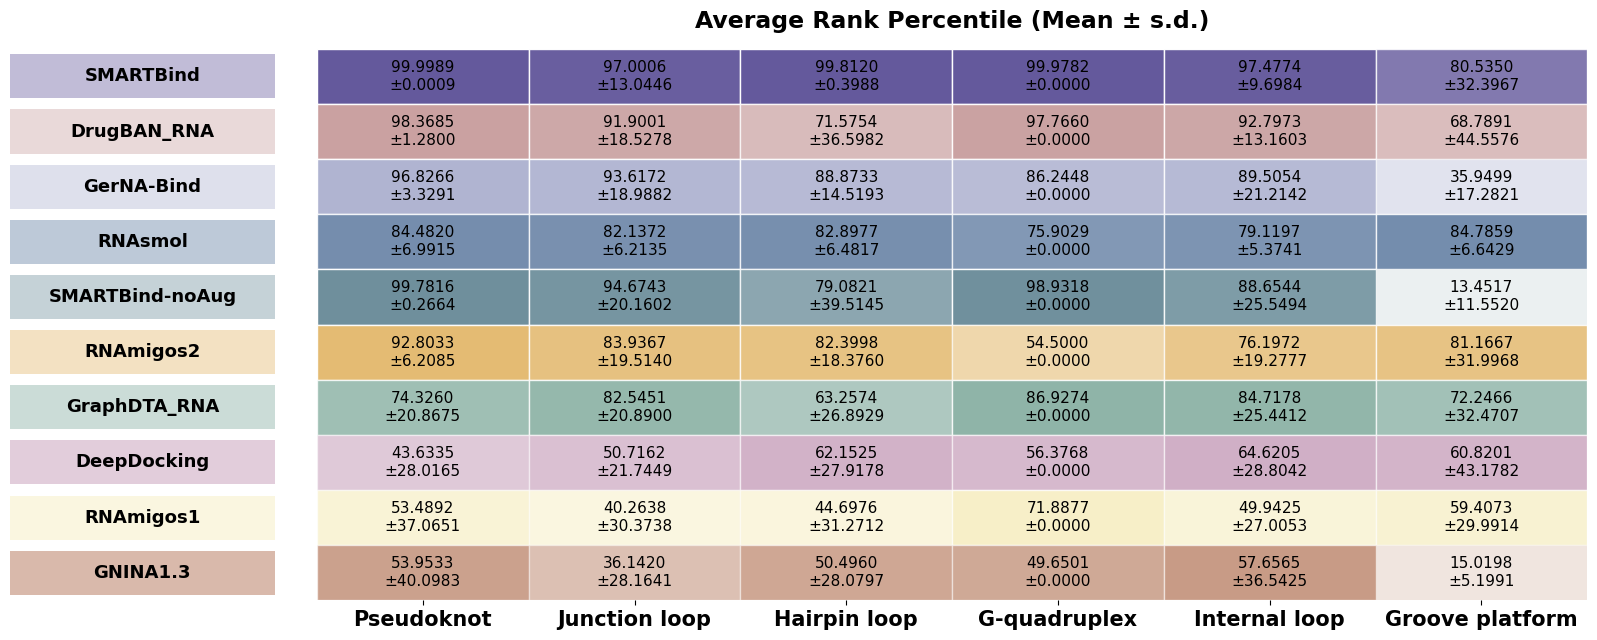

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from io import StringIO
from collections import defaultdict

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	0	0.0218	28.1123	45.5	24.0971	1.0682	13.7552	50.3499	43.6232	2.234	13.0726
0	0	0.0019	20.5276	3.37	11.4852	0.5162	6.6612	27.6688	43.6774	3.1023	44.3417
0	0	0.0012	30.0494	3.86	11.4777	0.136	2.8293	18.4312	36.9397	1.0216	29.5344
0	0	1.3134	13.71	18.37	11.4138	98.5111	26.1495	53.1874	3.2922	88.9497	22.6883
0	0	0.4112	29.5694	20.96	11.4578	99.3592	47.1395	11.4986	3.2304	41.6892	60.0259
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
0	0	0.0167	46.5686	3.67	11.4846	0.8486	4.5399	86.4612	29.5862	0.2191	38.3121
1	0	0.0007	52.0416	16.33	23.8038	2.8677	0.2728	0.8284	6.8369	0.0095	0.1798
1	0	0.0066	54.5291	17.71	23.8127	0.9953	0.1539	7.3622	4.0725	0.0086	0.1771
1	0	0.0038	17.2288	17.7	23.8229	1.8325	0.1257	1.215	2.9371	0.0048	0.3753
1	0	0.0011	40.3711	14.72	23.8177	2.6775	0.1694	0.3101	9.2101	0.0131	0.3472
1	0	0.0007	19.6737	17.66	23.9339	1.7206	0.1375	0.8858	6.5651	0.0152	0.0925
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
1	0	0.1517	38.2882	0.35	11.251	74.1658	55.3776	86.2841	3.559	4.0201	64.3318
1	0	56.8668	11.82	0.37	11.5081	88.4436	83.9511	79.2533	26.7791	82.6332	2.3322
0	0	0.0017	20.8755	15.3848	11.4979	0.4507	5.3955	27.3125	35.6933	10.1937	2.0355
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	0	0.002	26.6181	8.2086	11.4999	1.3145	0.037	31.4435	60.33	0.1495	20.8979
0	0	0.0021	28.053	31.0105	11.4999	1.9425	0.0656	45.2975	88.8545	4.1481	9.0918
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	0	0.0003	80.5214	2.2355	23.2556	0.2371	0.0106	86.7387	75.2199	0.1758	0.44
0	0	0.0162	38.3739	0.5947	11.4999	4.9781	4.171	71.3459	49.117	1.9008	63.7565
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
1	0	2.2076	73.0067	45.1691	11.4604	99.7153	53.4637	68.5215	5.5525	31.4947	30.8514
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	0	0.2907	52.6191	19.5973	24.0664	29.1305	12.0671	59.1727	37.4845	89.1704	79.6051
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
0	0	0.0013	47.5756	10.8691	11.4522	0.0892	5.0833	14.8915	49.313	0.5309	62.311
""".strip()

motif_3d = r"""
3D motif annotation
Pseudoknot / Junction loop / Hairpin loop
G-quadruplex / Internal loop
Pseudoknot / Junction loop / Hairpin loop
Pseudoknot / Junction loop / Hairpin loop
Hairpin loop
Hairpin loop
Junction loop / Internal loop
Hairpin loop / Junction loop
Internal loop
Internal loop
Internal loop
Internal loop
Internal loop
Groove platform
Groove platform
Groove platform / Junction loop
Junction loop
Junction loop
Internal loop / Junction loop
Internal loop / Junction loop
Internal loop / Junction loop
Internal loop / Junction loop
Internal loop / Junction loop
Internal loop / Junction loop
Junction loop
Internal loop
Hairpin loop / Junction loop
Internal loop
Internal loop
Internal loop / Junction loop
Hairpin loop / Junction loop
Hairpin loop
Hairpin loop
Hairpin loop / Junction loop
""".strip("\n")

# if a case belongs to multiple motifs, it is counted in all those motifs --- 3D motif annotation is not mutually exclusive
df = pd.read_csv(StringIO(raw), sep="\t")

motif_lines = [line.strip() for line in motif_3d.splitlines() if line.strip()]
if motif_lines and motif_lines[0].lower().startswith("3d motif"):
    motif_lines = motif_lines[1:]

if len(motif_lines) != len(df):
    raise ValueError(f"motif_3d has {len(motif_lines)} lines but raw has {len(df)} rows, they must match")

ordered_models = [c for c in df.columns if c not in ["Homology-based", "Ligand-based"]]
raw_data = {m: defaultdict(list) for m in ordered_models}
motif_order = []

for idx, motif_text in enumerate(motif_lines):
    motifs = [m.strip() for m in motif_text.split("/") if m.strip()]
    for motif in motifs:
        if motif not in motif_order:
            motif_order.append(motif)
        for model in ordered_models:
            raw_data[model][motif].append(float(df.loc[idx, model]))

raw_data = {m: dict(raw_data[m]) for m in raw_data}
rna_types = motif_order

model_colors = {
    "SMARTBind": "#64599C",
    "RNAmigos1": "#F4E9B3",
    "RNAmigos2": "#E2B668",
    "RNAsmol": "#5B789E",
    "SMARTBind-noAug": "#6E8F9C",
    "GerNA-Bind": "#AEB2D0",
    "GNINA1.3": "#A0522D",
    "DeepDocking": "#B784A7",
    "DrugBAN_RNA": "#C9A0A0",
    "GraphDTA_RNA": "#7FA99B",
}

palette = plt.get_cmap("tab20")
for i, m in enumerate(ordered_models):
    if m not in model_colors:
        model_colors[m] = palette(i % 20)

heatmap_stats = {}

for model in ordered_models:
    heatmap_stats[model] = {}

    for rna in rna_types:
        raw_vals = raw_data[model].get(rna, [])
        if len(raw_vals) == 0:
            processed_vals = [0.0]
        else:
            processed_vals = [100 - (v) for v in raw_vals]

        cell_mean = np.mean(processed_vals)
        cell_std = np.std(processed_vals, ddof=1) if len(processed_vals) > 1 else 0.0

        heatmap_stats[model][rna] = {"mean": cell_mean, "std": cell_std}

# sort models by their overall mean for the heatmap order
ordered_models = sorted(
    ordered_models,
    key=lambda m: np.mean([
        heatmap_stats[m][rna]["mean"] for rna in rna_types
    ]),
    reverse=True,
)

rows = len(ordered_models)
fig_h = max(6.5, rows * 0.6)
fig, ax_heatmap = plt.subplots(figsize=(16, fig_h))

# Left heatmap showing mean ± std for each model (rows) and RNA type (columns)
cols = len(rna_types)

ax_heatmap.set_xlim(0, cols)
ax_heatmap.set_ylim(0, rows)

label_width = 1.25
label_gap = 0.2

for i, model_name in enumerate(ordered_models):
    color = model_colors[model_name]
    y_pos = rows - 1 - i

    rect_label = patches.Rectangle(
        (-label_width - label_gap, y_pos + 0.1),
        label_width,
        0.8,
        linewidth=0,
        facecolor=color,
        alpha=0.4,
        clip_on=False,
    )
    ax_heatmap.add_patch(rect_label)

    ax_heatmap.text(
        -label_width / 2 - label_gap,
        y_pos + 0.5,
        model_name,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        clip_on=False,
    )

    for j, rna in enumerate(rna_types):
        stats = heatmap_stats[model_name][rna]
        mean_val = stats["mean"]
        std_val = stats["std"]

        alpha = max(0.1, min(1.0, mean_val * 0.01))

        rect = patches.Rectangle(
            (j, y_pos),
            1,
            1,
            linewidth=1,
            edgecolor="white",
            facecolor=color,
            alpha=alpha,
        )
        ax_heatmap.add_patch(rect)

        # RNAmigos1的文字颜色固定为黑色
        if model_name == "RNAmigos1":
            text_color = "black"
        elif model_name == "GraphDTA_RNA":
            text_color = "black"
        elif model_name == "DeepDocking":
            text_color = "black"
        else:
            text_color = "black" if alpha > 0.6 else "black"
        label_text = f"{mean_val:.4f}\n±{std_val:.4f}"
        ax_heatmap.text(
            j + 0.5,
            y_pos + 0.5,
            label_text,
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            linespacing=1.25,
        )

ax_heatmap.set_xticks(np.arange(cols) + 0.5)
ax_heatmap.set_xticklabels(rna_types, rotation=0, ha="center", fontsize=15, fontweight="bold")
ax_heatmap.set_yticks([])
ax_heatmap.set_title("Average Rank Percentile (Mean ± s.d.)", fontsize=17, pad=15, fontweight="bold")
for sp in ax_heatmap.spines.values():
    sp.set_visible(False)

plt.tight_layout()
plt.savefig("nc_revision/avg_rank_percentile_by3dmotif_joint.png", dpi=600, bbox_inches="tight")
plt.savefig("nc_revision/avg_rank_percentile_by3dmotif_joint.pdf", dpi=600, bbox_inches="tight")
plt.show()

    SMARTBind  RNAmigos2  RNAsmol  SMARTBind-noAug  GerNA-Bind  GraphDTA_RNA  \
0      0.0001    14.3600  23.5911           0.0029      0.0297        3.1459   
1      0.0001     9.1100  23.5854           0.5363      8.4196       18.0785   
2      1.3765    55.7800  22.8833          97.0354     52.8215       16.5963   
3      0.0002    15.8059  23.5790           0.0064      0.0213       19.3567   
4      0.0474    24.1831  23.3187           0.2771      0.0048        0.1278   
5      0.0003     7.6258  23.5854           0.2383      0.0091        0.3541   
6      0.0004     3.9801  23.6448           0.2595      0.0183        0.2289   
7      0.0152    17.9950  23.8035           0.4251      0.0014        2.6508   
8      0.4717    61.6866  24.0098          38.7512     24.5767        0.1198   
9     40.1000    21.9897  24.1316          33.6636     73.0269       90.3301   
10     0.0011    63.2140  23.8297           0.0602      0.0081       11.5049   
11     0.0145    69.3553  23.7953       

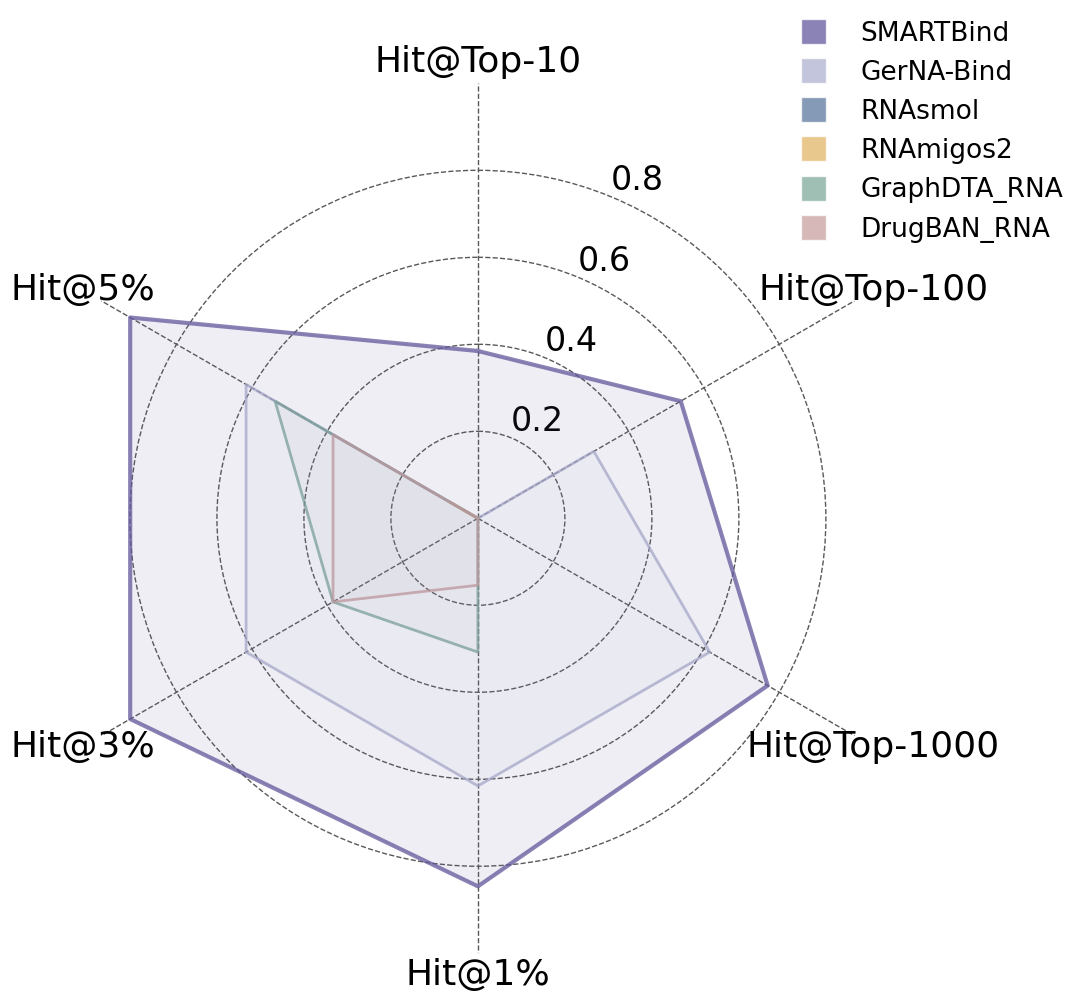

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from io import StringIO

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
""".strip()

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
""".strip()

df = pd.read_csv(StringIO(raw), sep="\t")
if "GNINA" in df.columns and "GNINA1.3" not in df.columns:
    df = df.rename(columns={"GNINA": "GNINA1.3"})

# Filter rows where Homology-based=1 AND Ligand-based=1
# df_filtered = df[(df["Homology-based"] == 1) & (df["Ligand-based"] == 1)]
df_filtered = df[(df["Ligand-based"] == 1)]
# df_filtered = df

print(df_filtered[["SMARTBind", "RNAmigos2", "RNAsmol", "SMARTBind-noAug", "GerNA-Bind", "GraphDTA_RNA", "DrugBAN_RNA"]])

models_list = ["SMARTBind", "RNAmigos2", "RNAsmol", "SMARTBind-noAug", "GerNA-Bind", "GraphDTA_RNA", "DrugBAN_RNA"]
raw_data = {model: [] for model in models_list}

for _, row in df_filtered.iterrows():
    for model in models_list:
        raw_data[model].append(row[model])

model_colors = {
    "SMARTBind": "#64599C",
    "RNAmigos1": "#F4E9B3", 
    "RNAmigos2": "#E2B668",
    "RNAsmol": "#5B789E",
    "SMARTBind-noAug": "#6E8F9C",
    "GerNA-Bind": "#AEB2D0",
    "GraphDTA_RNA": "#7FA99B",
    "DrugBAN_RNA": "#C9A0A0",
}

ordered_models = ['SMARTBind', 'GerNA-Bind', 'RNAsmol', 'RNAmigos2', 'GraphDTA_RNA', 'DrugBAN_RNA']

metrics = ["Hit@Top-10", "Hit@Top-100", "Hit@Top-1000", "Hit@1%", "Hit@3%", "Hit@5%"]
thresholds = [0.001, 0.01, 0.1, 1.0, 3.0, 5.0] 

radar_data = {}

for model in ordered_models:
    all_ranks = raw_data[model]
    
    total_count = len(all_ranks)
    scores = []
    
    if total_count > 0:
        for t in thresholds:
            hits = sum(1 for r in all_ranks if r <= t)
            scores.append(hits / total_count)
    else:
        scores = [0] * 6
        
    radar_data[model] = scores

N = len(metrics) # N = 6
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

for i in range(N):
    theta = angles[i]
    r = 1.05
    ax.text(theta, r, metrics[i],
            rotation=0,
            rotation_mode="anchor",
            ha="center", va="center",
            fontsize=26)

ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="#000000", size=24)
ax.grid(True, color='#595959', linestyle='--', linewidth=1)
ax.spines['polar'].set_visible(False)

for model in ordered_models:
    values = radar_data[model]
    values += values[:1]     
    color = model_colors[model]
    
    if model == "SMARTBind":
        lw = 3
        zorder = 10
        alpha_fill = 0.1
    else:
        lw = 2
        zorder = 5
        alpha_fill = 0.05
        
    ax.plot(angles, values, linewidth=lw, color=color, label=model, zorder=zorder, alpha=0.75)
    ax.fill(angles, values, color=color, alpha=alpha_fill, zorder=zorder)

legend_elements = [Line2D([0], [0], marker='s', color='w', 
                         markerfacecolor=model_colors[model], 
                         markersize=18, label=model, alpha=0.75)
                  for model in ordered_models]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1.1),
           fancybox=False, shadow=False, frameon=False, fontsize=19)

plt.tight_layout()
plt.savefig('nc_revision/radar_6_metrics_with_topN_both_filters.png', dpi=600, bbox_inches='tight')
plt.show()

SMARTBind recall at top 0.001%: 0.385, 5/13
SMARTBind recall at top 0.0011233240329780276%: 0.462, 6/13
SMARTBind recall at top 0.0012618568830660211%: 0.462, 6/13
SMARTBind recall at top 0.0014174741629268048%: 0.462, 6/13
SMARTBind recall at top 0.0015922827933410922%: 0.462, 6/13
SMARTBind recall at top 0.001788649529057435%: 0.462, 6/13
SMARTBind recall at top 0.002009233002565048%: 0.538, 7/13
SMARTBind recall at top 0.002257019719633919%: 0.538, 7/13
SMARTBind recall at top 0.0025353644939701114%: 0.538, 7/13
SMARTBind recall at top 0.002848035868435802%: 0.538, 7/13
SMARTBind recall at top 0.0031992671377973846%: 0.538, 7/13
SMARTBind recall at top 0.003593813663804626%: 0.538, 7/13
SMARTBind recall at top 0.004037017258596553%: 0.538, 7/13
SMARTBind recall at top 0.004534878508128582%: 0.538, 7/13
SMARTBind recall at top 0.0050941380148163806%: 0.538, 7/13
SMARTBind recall at top 0.00572236765935022%: 0.538, 7/13
SMARTBind recall at top 0.006428073117284319%: 0.538, 7/13
SMARTB

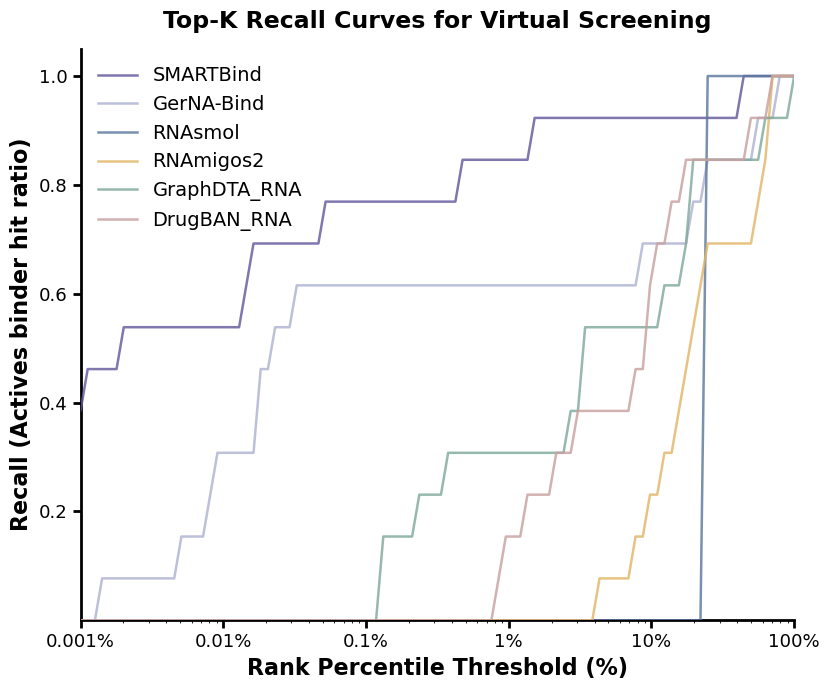

In [3]:
# Top-K Recall Curves
# Shows recall (sensitivity) as we screen more compounds

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from matplotlib.lines import Line2D

# Load data for model comparison
raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	0	0.0218	28.1123	45.5	24.0971	1.0682	13.7552	50.3499	43.6232	2.234	13.0726
0	0	0.0019	20.5276	3.37	11.4852	0.5162	6.6612	27.6688	43.6774	3.1023	44.3417
0	0	0.0012	30.0494	3.86	11.4777	0.136	2.8293	18.4312	36.9397	1.0216	29.5344
0	0	1.3134	13.71	18.37	11.4138	98.5111	26.1495	53.1874	3.2922	88.9497	22.6883
0	0	0.4112	29.5694	20.96	11.4578	99.3592	47.1395	11.4986	3.2304	41.6892	60.0259
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
0	0	0.0167	46.5686	3.67	11.4846	0.8486	4.5399	86.4612	29.5862	0.2191	38.3121
1	0	0.0007	52.0416	16.33	23.8038	2.8677	0.2728	0.8284	6.8369	0.0095	0.1798
1	0	0.0066	54.5291	17.71	23.8127	0.9953	0.1539	7.3622	4.0725	0.0086	0.1771
1	0	0.0038	17.2288	17.7	23.8229	1.8325	0.1257	1.215	2.9371	0.0048	0.3753
1	0	0.0011	40.3711	14.72	23.8177	2.6775	0.1694	0.3101	9.2101	0.0131	0.3472
1	0	0.0007	19.6737	17.66	23.9339	1.7206	0.1375	0.8858	6.5651	0.0152	0.0925
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
1	0	0.1517	38.2882	0.35	11.251	74.1658	55.3776	86.2841	3.559	4.0201	64.3318
1	0	56.8668	11.82	0.37	11.5081	88.4436	83.9511	79.2533	26.7791	82.6332	2.3322
0	0	0.0017	20.8755	15.3848	11.4979	0.4507	5.3955	27.3125	35.6933	10.1937	2.0355
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	0	0.002	26.6181	8.2086	11.4999	1.3145	0.037	31.4435	60.33	0.1495	20.8979
0	0	0.0021	28.053	31.0105	11.4999	1.9425	0.0656	45.2975	88.8545	4.1481	9.0918
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	0	0.0003	80.5214	2.2355	23.2556	0.2371	0.0106	86.7387	75.2199	0.1758	0.44
0	0	0.0162	38.3739	0.5947	11.4999	4.9781	4.171	71.3459	49.117	1.9008	63.7565
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
1	0	2.2076	73.0067	45.1691	11.4604	99.7153	53.4637	68.5215	5.5525	31.4947	30.8514
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	0	0.2907	52.6191	19.5973	24.0664	29.1305	12.0671	59.1727	37.4845	89.1704	79.6051
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
0	0	0.0013	47.5756	10.8691	11.4522	0.0892	5.0833	14.8915	49.313	0.5309	62.311
""".strip()

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
""".strip()

df_recall = pd.read_csv(StringIO(raw), sep="\t")
if "GNINA" in df_recall.columns and "GNINA1.3" not in df_recall.columns:
    df_recall = df_recall.rename(columns={"GNINA": "GNINA1.3"})

# Keep only the requested models
models_recall = ["SMARTBind", "GerNA-Bind", "RNAsmol", "RNAmigos2", "GraphDTA_RNA", "DrugBAN_RNA"]
model_colors_recall = {
    "SMARTBind": "#64599C",
    "GerNA-Bind": "#AEB2D0",
    "RNAsmol": "#5B789E",
    "RNAmigos2": "#E2B668",
    "GraphDTA_RNA": "#7FA99B",
    "DrugBAN_RNA": "#C9A0A0",
}
line_styles_recall = {
    "SMARTBind": "-",
    "GerNA-Bind": "-",
    "RNAsmol": "-",
    "RNAmigos2": "-",
    "GraphDTA_RNA": "-",
    "DrugBAN_RNA": "-"
}

fig, ax = plt.subplots(figsize=(12*0.7, 7))

# Define screening thresholds (in rank percentile)
thresholds = np.logspace(-3, 2, 100)  # From 0.001% to 100%

for model in models_recall:
    ranks = df_recall[model].values
    total_actives = len(ranks)
    
    recall_values = []
    for threshold in thresholds:
        actives_found = np.sum(ranks <= threshold)
        recall = actives_found / total_actives
        recall_values.append(recall)
        if model == "SMARTBind":
            print(f"{model} recall at top {threshold}%: {recall:.3f}, {actives_found}/{total_actives}")
    
    lw = 1.8 if model == "SMARTBind" else 1.8
    alpha = 0.82 if model == "SMARTBind" else 0.82
    zorder = 6 if model == "SMARTBind" else 6
    ls = line_styles_recall[model]
    
    ax.plot(thresholds, recall_values, 
            label=model, color=model_colors_recall[model], 
            linewidth=lw, linestyle=ls, alpha=alpha, zorder=zorder, solid_capstyle='round')

ax.set_xlabel('Rank Percentile Threshold (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Recall (Actives binder hit ratio)', fontsize=16, fontweight='bold')
ax.set_title('Top-K Recall Curves for Virtual Screening', fontsize=17, fontweight='bold', pad=15)
ax.set_xscale('log')
ax.set_xlim(0.001, 100)
ax.set_ylim(0, 1.05)
# ax.grid(True, which='major', alpha=0.25, linestyle='--', linewidth=0.9)
# ax.grid(True, which='minor', alpha=0.12, linestyle=':', linewidth=0.7)

# Legend uses real line styles
legend_elements = [Line2D([0], [0], color=model_colors_recall[model],
                         linestyle=line_styles_recall[model],
                         linewidth=1.8 if model == "SMARTBind" else 1.8,
                         alpha=0.82 if model == "SMARTBind" else 0.82,
                         label=model)
                  for model in models_recall]
ax.legend(handles=legend_elements, fontsize=14, frameon=False, 
          fancybox=True, shadow=False, loc='upper left')

# Format x-axis with percentage labels
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4g}%' if x < 1 else f'{x:.3g}%'))


# Remove 0 from y-axis ticks
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

# Make all spines (borders) bold
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', labelsize=13, width=2, length=6)
plt.tight_layout()
plt.savefig('nc_revision/topk_recall_curves.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/topk_recall_curves.pdf', bbox_inches='tight')
plt.show()

# # Print recall at key thresholds
# print("\nRecall at Key Screening Thresholds:")
# for threshold in [0.01, 0.1, 1.0, 5.0]:
#     print(f"\n--- Recall at Top {threshold}% ---")
#     for model in models_recall:
#         ranks = df_recall[model].values
#         recall = np.sum(ranks <= threshold) / len(ranks)
#         print(f"{model}: {recall:.3f}")

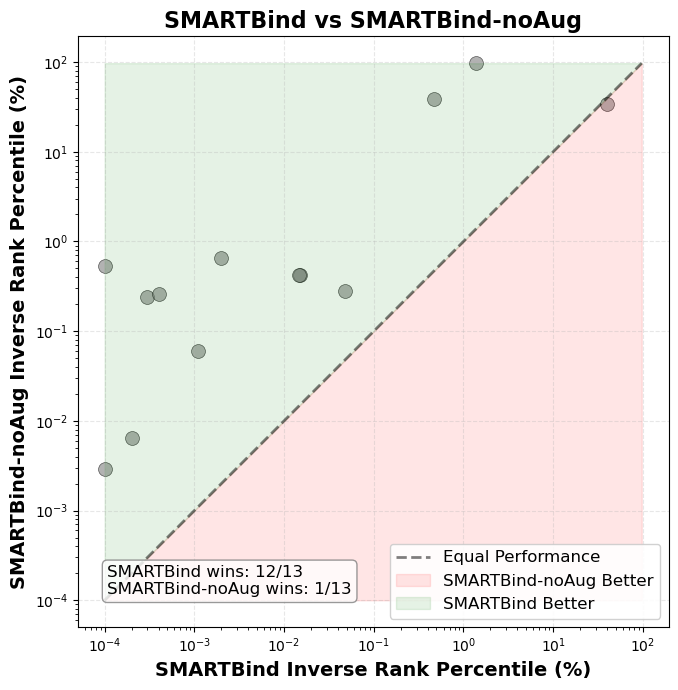

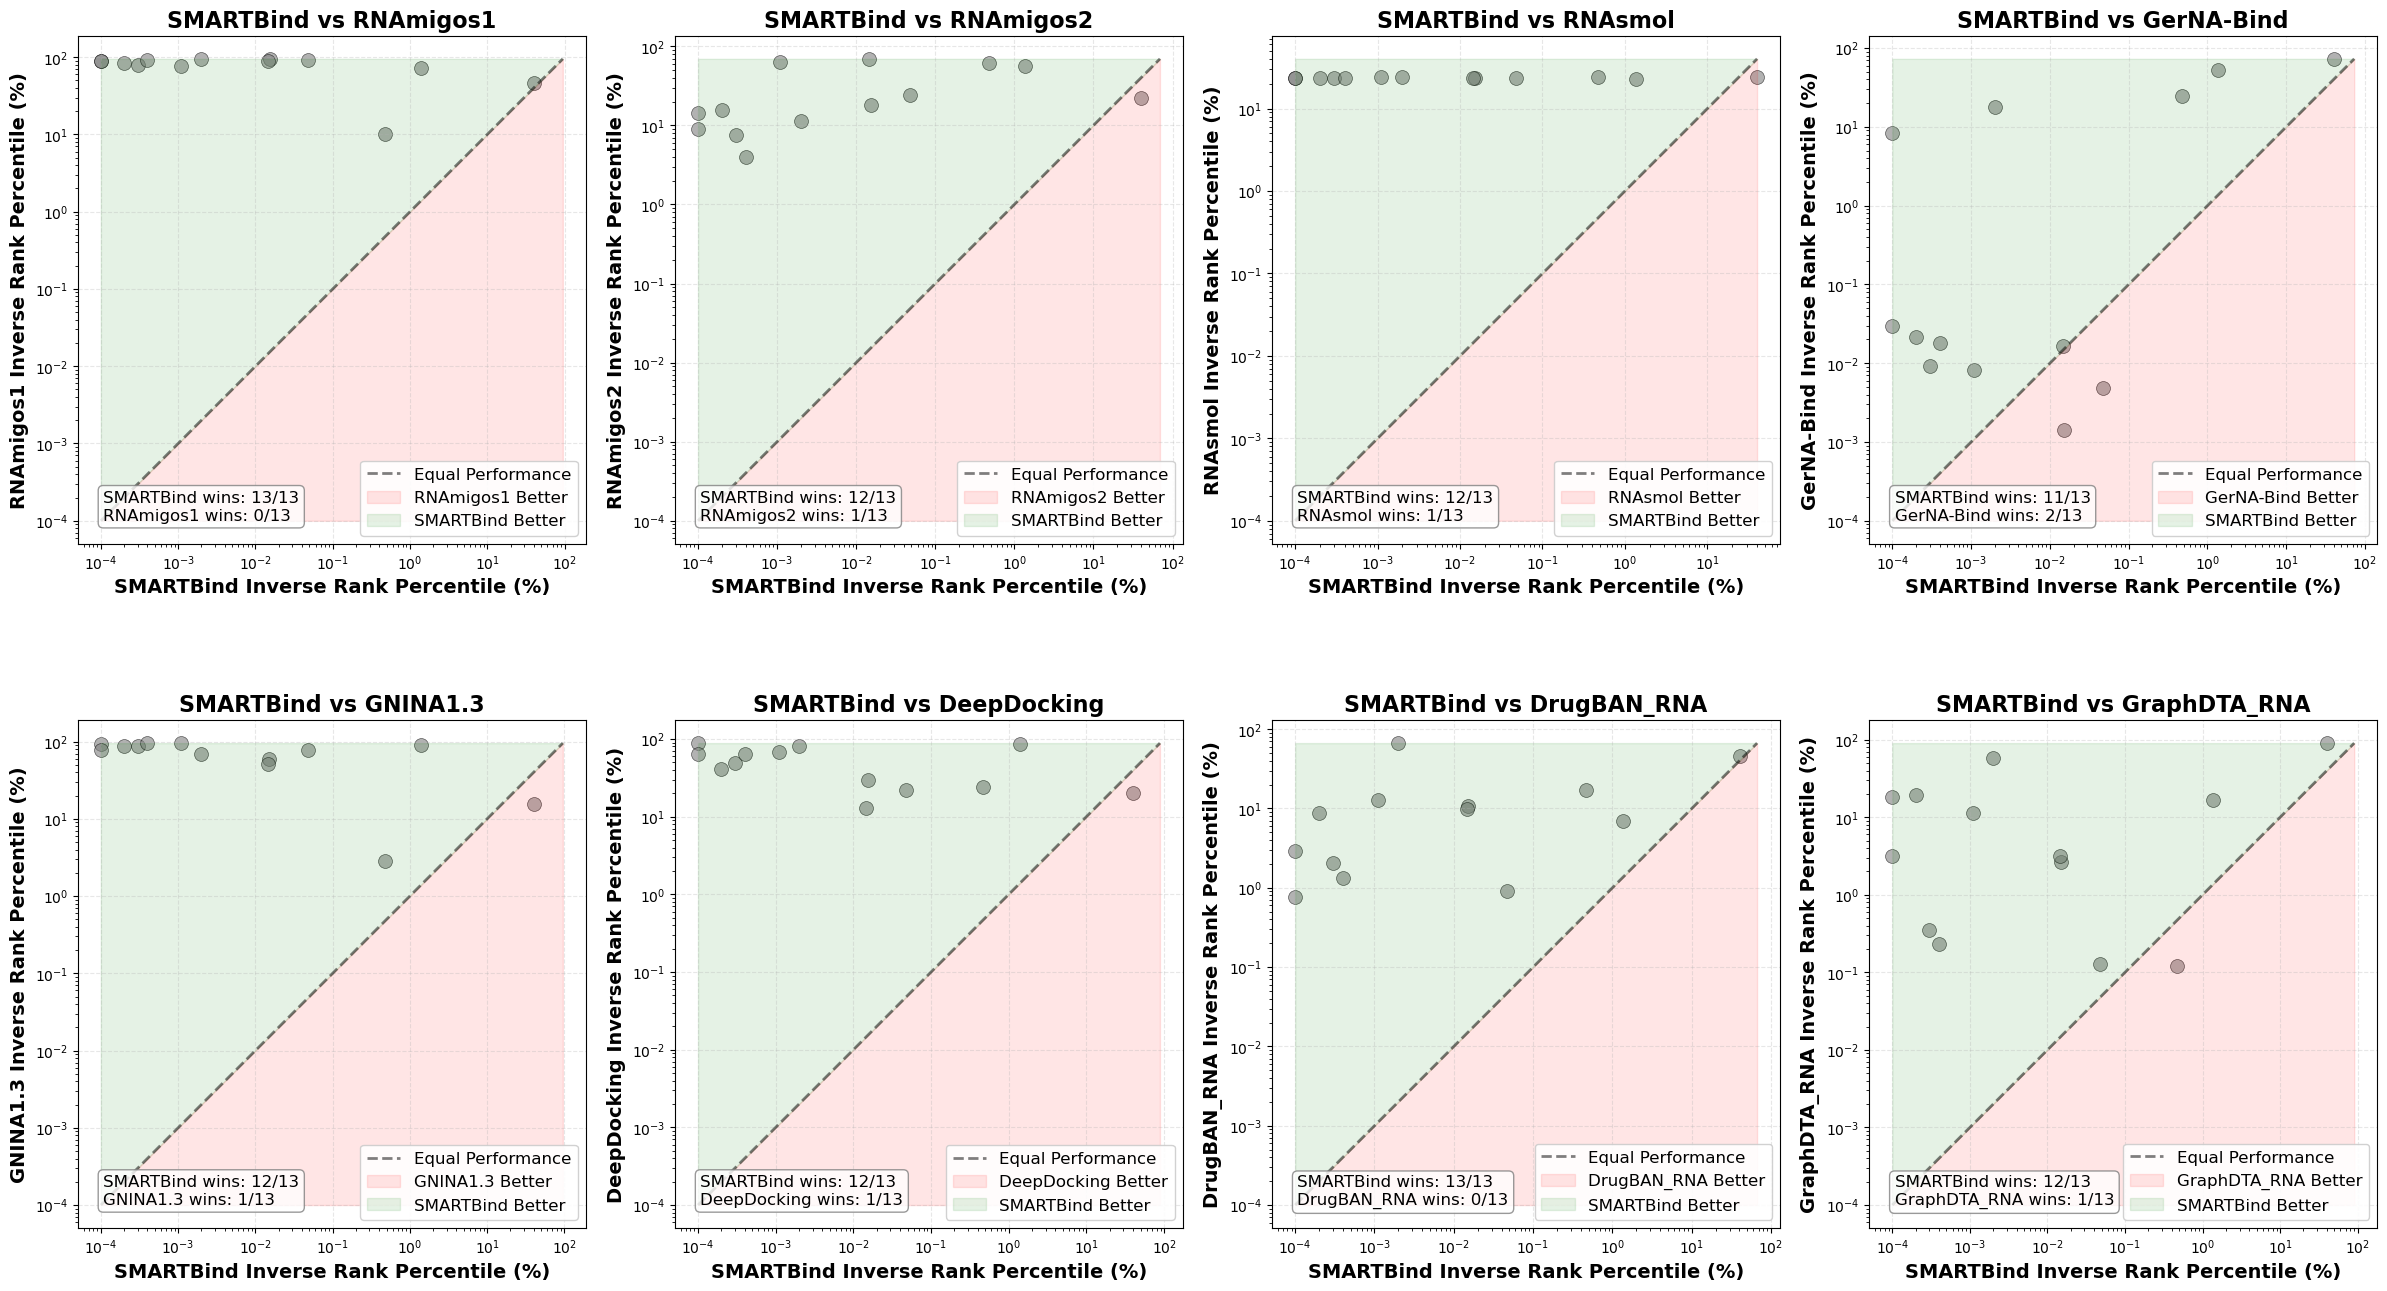

In [4]:
from scipy.stats import spearmanr, pearsonr

def plot_smartbind_vs_model(ax, df, comparison_model):
    x = df['SMARTBind'].values
    y = df[comparison_model].values

    ax.scatter(
        x, y, alpha=0.6, s=100,
        color='grey',
        edgecolors='black', linewidth=0.5
    )

    # Diagonal line for equal performance
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot(
        [min_val, max_val], [min_val, max_val], 'k--',
        linewidth=2, alpha=0.5, label='Equal Performance'
    )

    # Color regions for better/worse performance
    ax.fill_between(
        [min_val, max_val], [min_val, min_val], [min_val, max_val],
        alpha=0.1, color='red', label=f'{comparison_model} Better'
    )
    ax.fill_between(
        [min_val, max_val], [min_val, max_val], [max_val, max_val],
        alpha=0.1, color='green', label='SMARTBind Better'
    )

    # Calculate correlations (kept for potential future use)
    spearman_corr, spearman_p = spearmanr(x, y)
    pearson_corr, pearson_p = pearsonr(x, y)

    # Calculate win/loss statistics
    smartbind_wins = np.sum(x < y)
    comparison_wins = np.sum(y < x)

    stats_text = f'SMARTBind wins: {smartbind_wins}/{len(x)}\n'
    stats_text += f'{comparison_model} wins: {comparison_wins}/{len(x)}'

    ax.text(
        0.05, 0.105, stats_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    # Log scale
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Labels and title
    ax.set_xlabel('SMARTBind Inverse Rank Percentile (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'{comparison_model} Inverse Rank Percentile (%)', fontsize=14, fontweight='bold')
    ax.set_title(f'SMARTBind vs {comparison_model}', fontsize=16, fontweight='bold')

    # Legend
    ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

    # Grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Equal aspect ratio for square appearance
    ax.set_aspect('equal', adjustable='box')

# ------------------------------------------
# 1) SMARTBind vs SMARTBind-noAug (single)
# ------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
plot_smartbind_vs_model(ax, df, 'SMARTBind-noAug')

plt.tight_layout()
plt.savefig('nc_revision/model_comparison_scatter_smartbind_vs_noaug.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/model_comparison_scatter_smartbind_vs_noaug.pdf', bbox_inches='tight')
plt.show()

# ------------------------------------------
# 2) SMARTBind vs other six models (2x4)
# ------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(24, 14))
axes = axes.flatten()

comparison_models = ['RNAmigos1', 'RNAmigos2', 'RNAsmol', 'GerNA-Bind', 'GNINA1.3', 'DeepDocking', 'DrugBAN_RNA', 'GraphDTA_RNA']

for idx, comparison_model in enumerate(comparison_models):
    plot_smartbind_vs_model(axes[idx], df, comparison_model)

plt.tight_layout()
plt.savefig('nc_revision/model_comparison_scatter_2x3.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/model_comparison_scatter_2x3.pdf', bbox_inches='tight')
plt.show()

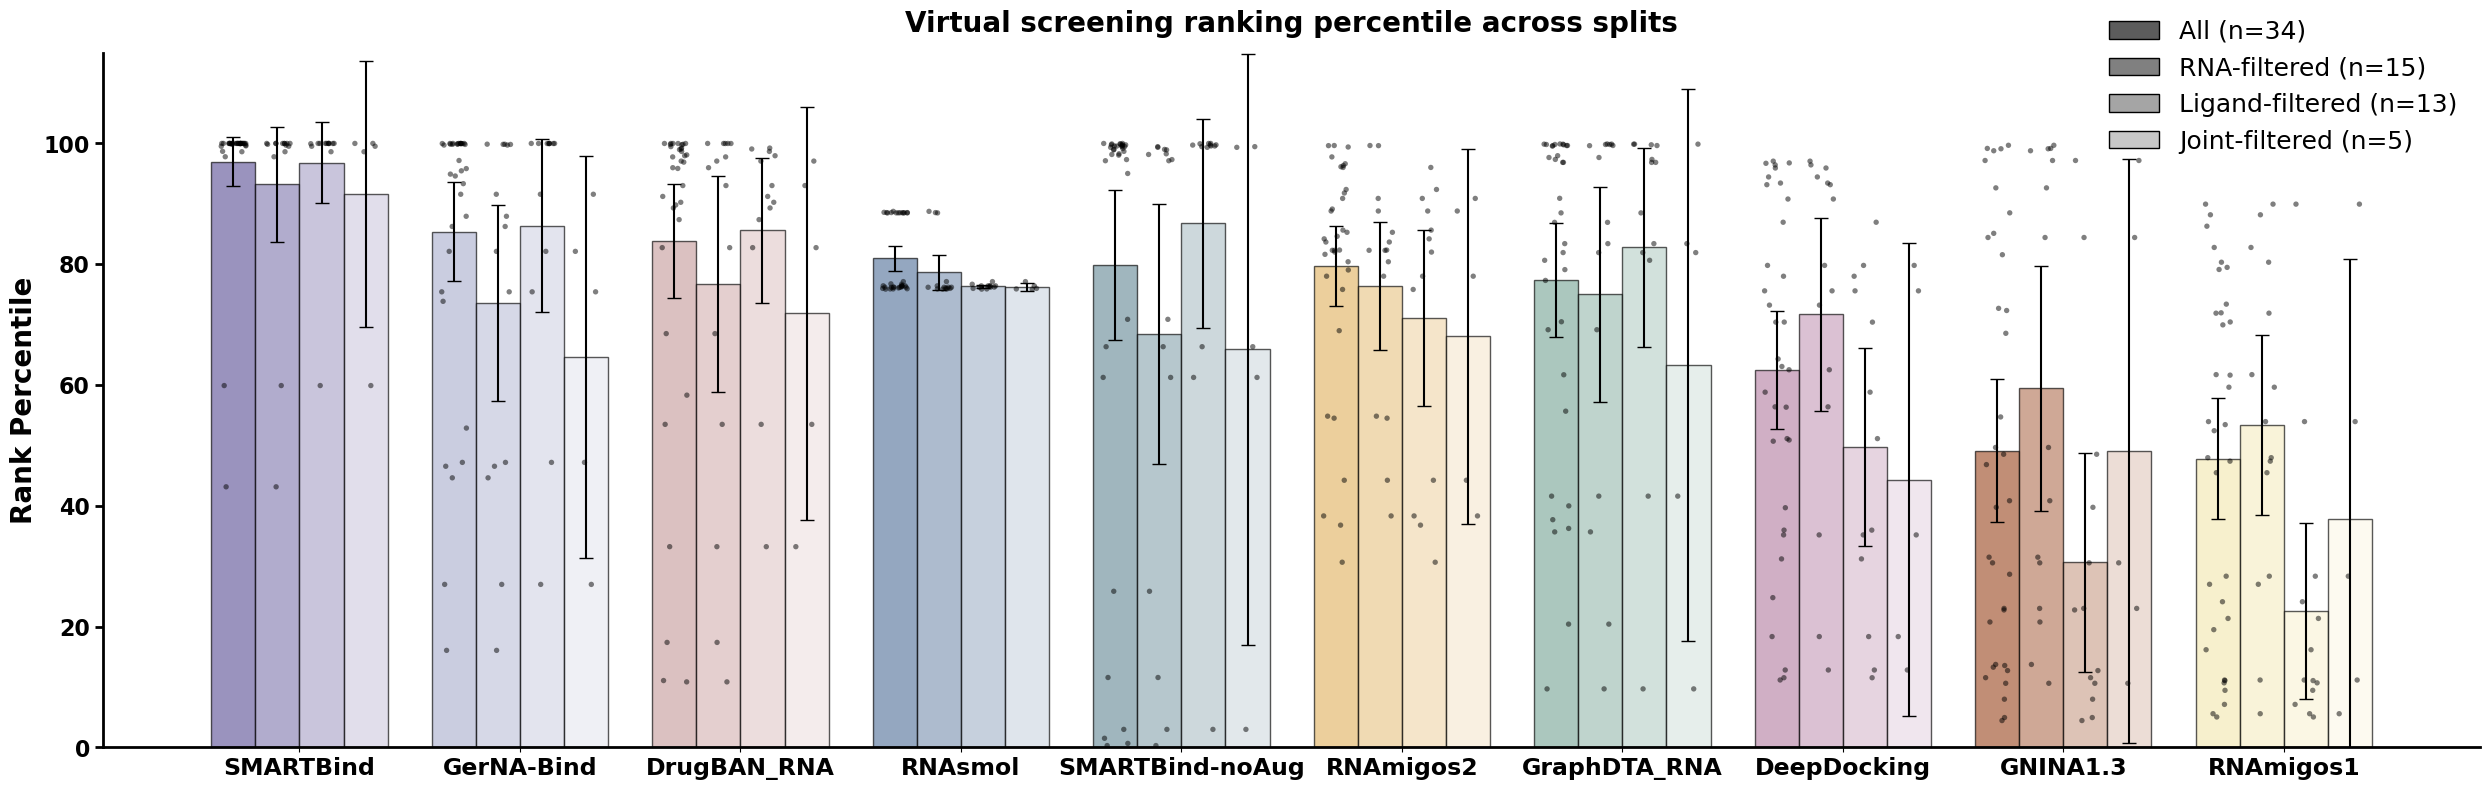

Statistics Summary (Success Score = 100 - Rank Percentile):

All (n=34):
--------------------------------------------------------------------------------
  SMARTBind           :  96.9603 (mean),  11.7250 (std), ±  4.0910 (95% CI)
  GerNA-Bind          :  85.3416 (mean),  23.4657 (std), ±  8.1876 (95% CI)
  DrugBAN_RNA         :  83.8515 (mean),  27.0490 (std), ±  9.4378 (95% CI)
  RNAsmol             :  80.9573 (mean),   6.0602 (std), ±  2.1145 (95% CI)
  SMARTBind-noAug     :  79.9019 (mean),  35.7029 (std), ± 12.4573 (95% CI)
  RNAmigos2           :  79.7082 (mean),  19.0504 (std), ±  6.6470 (95% CI)
  GraphDTA_RNA        :  77.3868 (mean),  26.8673 (std), ±  9.3744 (95% CI)
  DeepDocking         :  62.4635 (mean),  27.8552 (std), ±  9.7191 (95% CI)
  GNINA1.3            :  49.1122 (mean),  33.9226 (std), ± 11.8362 (95% CI)
  RNAmigos1           :  47.7538 (mean),  28.7567 (std), ± 10.0337 (95% CI)

RNA-filtered (n=15):
----------------------------------------------------------------

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy.stats import t

# Load the data
raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	0	0.0218	28.1123	45.5	24.0971	1.0682	13.7552	50.3499	43.6232	2.234	13.0726
0	0	0.0019	20.5276	3.37	11.4852	0.5162	6.6612	27.6688	43.6774	3.1023	44.3417
0	0	0.0012	30.0494	3.86	11.4777	0.136	2.8293	18.4312	36.9397	1.0216	29.5344
0	0	1.3134	13.71	18.37	11.4138	98.5111	26.1495	53.1874	3.2922	88.9497	22.6883
0	0	0.4112	29.5694	20.96	11.4578	99.3592	47.1395	11.4986	3.2304	41.6892	60.0259
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
0	0	0.0167	46.5686	3.67	11.4846	0.8486	4.5399	86.4612	29.5862	0.2191	38.3121
1	0	0.0007	52.0416	16.33	23.8038	2.8677	0.2728	0.8284	6.8369	0.0095	0.1798
1	0	0.0066	54.5291	17.71	23.8127	0.9953	0.1539	7.3622	4.0725	0.0086	0.1771
1	0	0.0038	17.2288	17.7	23.8229	1.8325	0.1257	1.215	2.9371	0.0048	0.3753
1	0	0.0011	40.3711	14.72	23.8177	2.6775	0.1694	0.3101	9.2101	0.0131	0.3472
1	0	0.0007	19.6737	17.66	23.9339	1.7206	0.1375	0.8858	6.5651	0.0152	0.0925
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
1	0	0.1517	38.2882	0.35	11.251	74.1658	55.3776	86.2841	3.559	4.0201	64.3318
1	0	56.8668	11.82	0.37	11.5081	88.4436	83.9511	79.2533	26.7791	82.6332	2.3322
0	0	0.0017	20.8755	15.3848	11.4979	0.4507	5.3955	27.3125	35.6933	10.1937	2.0355
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	0	0.002	26.6181	8.2086	11.4999	1.3145	0.037	31.4435	60.33	0.1495	20.8979
0	0	0.0021	28.053	31.0105	11.4999	1.9425	0.0656	45.2975	88.8545	4.1481	9.0918
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	0	0.0003	80.5214	2.2355	23.2556	0.2371	0.0106	86.7387	75.2199	0.1758	0.44
0	0	0.0162	38.3739	0.5947	11.4999	4.9781	4.171	71.3459	49.117	1.9008	63.7565
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
1	0	2.2076	73.0067	45.1691	11.4604	99.7153	53.4637	68.5215	5.5525	31.4947	30.8514
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	0	0.2907	52.6191	19.5973	24.0664	29.1305	12.0671	59.1727	37.4845	89.1704	79.6051
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
0	0	0.0013	47.5756	10.8691	11.4522	0.0892	5.0833	14.8915	49.313	0.5309	62.311
""".strip()


df = pd.read_csv(StringIO(raw), sep="\t")

# Generate random placeholder data for 3 new models
rng = np.random.default_rng(42)
n_samples = len(df)
# df["DeepDocking"] = rng.uniform(10, 70, n_samples)

# Define models and colors (including new placeholder models)
models = ["SMARTBind", "SMARTBind-noAug", "GNINA1.3", "DeepDocking", "GerNA-Bind", "RNAsmol", "RNAmigos2", "RNAmigos1", "DrugBAN_RNA", "GraphDTA_RNA"]
base_model_colors = {
    "SMARTBind": "#64599C",
    "RNAmigos1": "#F4E9B3", 
    "RNAmigos2": "#E2B668",
    "RNAsmol": "#5B789E",
    "SMARTBind-noAug": "#6E8F9C",
    "GNINA1.3": "#A0522D",
    "DeepDocking": "#B784A7",
    "GerNA-Bind": "#AEB2D0",
    "DrugBAN_RNA": "#C9A0A0",
    "GraphDTA_RNA": "#7FA99B",
}

# Define filter groups
filters = {
    "All": df,
    "RNA-filtered": df[df["Homology-based"] == 1],
    "Ligand-filtered": df[df["Ligand-based"] == 1],
    "Joint-filtered": df[(df["Homology-based"] == 1) & (df["Ligand-based"] == 1)]
}

# Create gray-black gradient for legend (lighter by two shades)
legend_colors = {
    "All": "#5C5C5C",      # Darkest (lightened)
    "RNA-filtered": "#808080",
    "Ligand-filtered": "#A5A5A5",
    "Joint-filtered": "#C8C8C8"      # Lightest (lightened)
}

# Create gradient colors for each model (darker to lighter for All, Homology, Ligand, Both)
def create_gradient_colors(base_color, n=4):
    """Create n gradient colors from base color (darker) to lighter"""
    base_rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n):
        factor = 1.0 - 0.7 * (i / (n - 1))  # 1.0 to 0.3
        new_rgb = tuple(1 - factor * (1 - c) for c in base_rgb)
        colors.append(new_rgb)
    return colors

# Create gradient colors for each model
model_gradients = {}
for model in models:
    model_gradients[model] = create_gradient_colors(base_model_colors[model], 4)

# Calculate statistics for each group and model
stats = {group: {model: {"mean": 0, "std": 0, "ci95": 0} for model in models} for group in filters.keys()}

for group_name, group_df in filters.items():
    for model in models:
        values = group_df[model].values
        raw_mean = np.mean(values)
        stats[group_name][model]["mean"] = 100 - raw_mean
        
        n = len(values)
        if n > 1:
            std = np.std(values, ddof=1)
            t_crit = t.ppf(0.975, df=n - 1)
            ci95 = t_crit * (std / np.sqrt(n))
        else:
            std = 0
            ci95 = 0
        stats[group_name][model]["std"] = std
        stats[group_name][model]["ci95"] = ci95

# Sort model order by comprehensive ranking in All split (high to low)
models = sorted(models, key=lambda m: stats["All"][m]["mean"], reverse=True)

# Plotting
fig, ax = plt.subplots(figsize=(20*1.25, 8))

group_names = list(filters.keys())
x = np.arange(len(models))
width = 0.2

for i, group_name in enumerate(group_names):
    for j, model in enumerate(models):
        mean = stats[group_name][model]["mean"]
        ci95 = stats[group_name][model]["ci95"]
        
        offset = width * (i - 1.5)
        color = model_gradients[model][i]
        
        ax.bar(x[j] + offset, mean, width, yerr=ci95,
               color=color, 
               alpha=0.65, capsize=5, edgecolor='black', linewidth=1)

# Overlay individual data points
for i, group_name in enumerate(group_names):
    group_df = filters[group_name]
    for j, model in enumerate(models):
        values = 100 - group_df[model].values
        offset = width * (i - 1.5)
        jitter = np.random.default_rng(42).uniform(-width*0.3, width*0.3, size=len(values))
        ax.scatter(x[j] + offset + jitter, values, 
                   color='black', s=15, alpha=0.5, zorder=10, edgecolors='none')

# Create custom legend
legend_handles = []
for group_name in group_names:
    handle = Rectangle((0, 0), 1, 1, fc=legend_colors[group_name], edgecolor='black', linewidth=1)
    legend_handles.append(handle)

legend_labels = [f'{group_name} (n={len(filters[group_name])})' for group_name in group_names]
ax.legend(legend_handles, legend_labels, fontsize=18, frameon=False, fancybox=True, shadow=False, loc='upper right', bbox_to_anchor=(1.0, 1.08))

ax.set_ylabel('Rank Percentile', fontsize=20, fontweight='bold')
ax.set_title('Virtual screening ranking percentile across splits', fontsize=20, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=17, rotation=0, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=16, width=2, length=6)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    
ax.set_ylim(0, 115)

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('nc_revision/performance_by_filter_groups_all.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/performance_by_filter_groups_all.pdf', bbox_inches='tight')
plt.show()

# Print statistics
print("Statistics Summary (Success Score = 100 - Rank Percentile):")
print("="*80)
for group_name in group_names:
    print(f"\n{group_name} (n={len(filters[group_name])}):")
    print("-"*80)
    for model in models:
        mean = stats[group_name][model]["mean"]
        std = stats[group_name][model]["std"]
        ci95 = stats[group_name][model]["ci95"]
        print(f"  {model:20s}: {mean:8.4f} (mean), {std:8.4f} (std), ±{ci95:8.4f} (95% CI)")

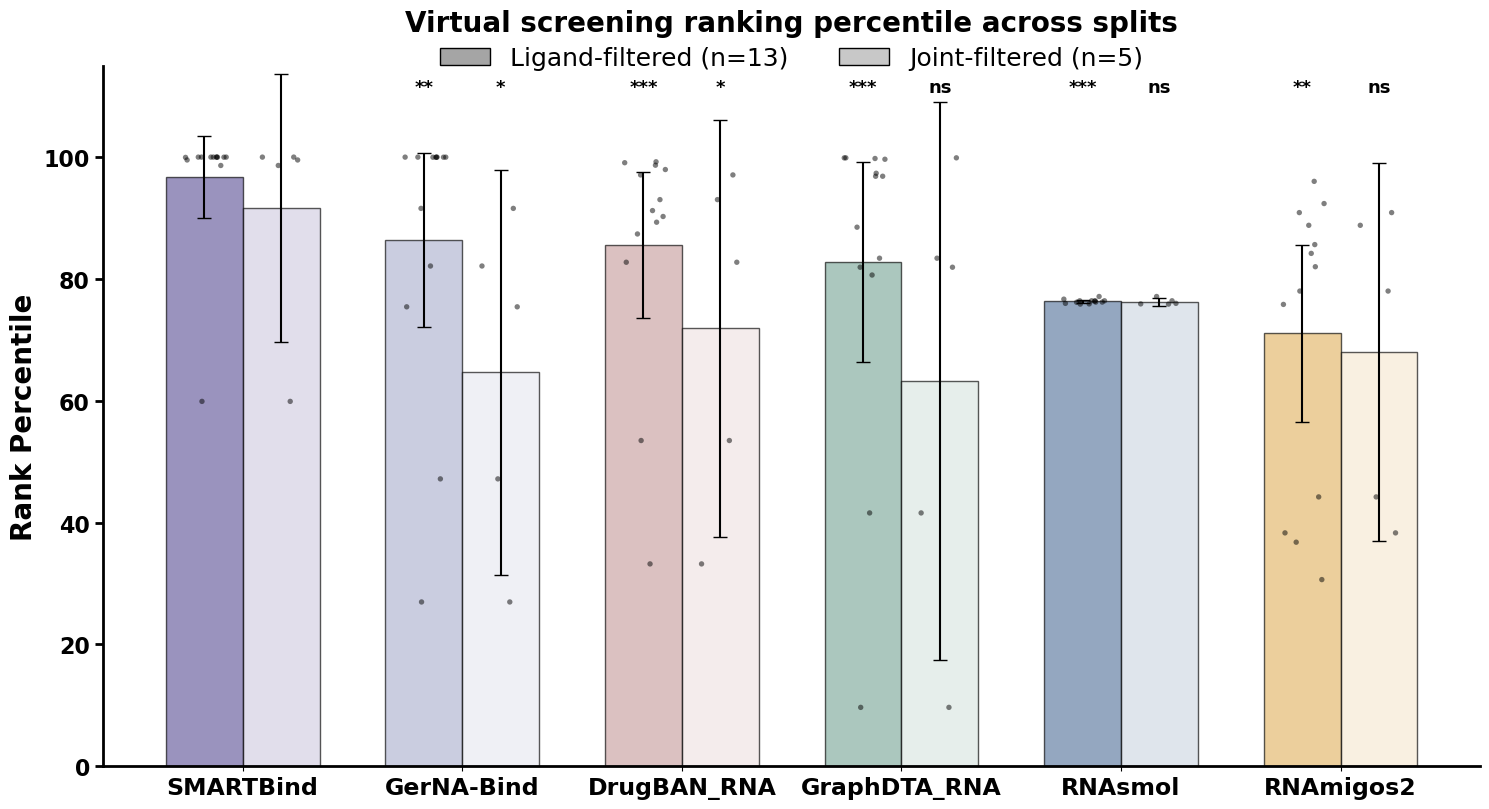

Statistics Summary (Success Score = 100 - Rank Percentile):

Ligand-filtered (n=13):
--------------------------------------------------------------------------------
  SMARTBind           :  96.7670 (mean),  11.0839 (std), ±  6.6980 (95% CI)
  GerNA-Bind          :  86.3976 (mean),  23.6506 (std), ± 14.2919 (95% CI)
  DrugBAN_RNA         :  85.5873 (mean),  19.8572 (std), ± 11.9996 (95% CI)
  GraphDTA_RNA        :  82.7656 (mean),  27.1514 (std), ± 16.4074 (95% CI)
  RNAsmol             :  76.3188 (mean),   0.3342 (std), ±  0.2020 (95% CI)
  RNAmigos2           :  71.0553 (mean),  24.0867 (std), ± 14.5555 (95% CI)

Joint-filtered (n=5):
--------------------------------------------------------------------------------
  SMARTBind           :  91.6099 (mean),  17.7353 (std), ± 22.0213 (95% CI)
  GerNA-Bind          :  64.6557 (mean),  26.7928 (std), ± 33.2677 (95% CI)
  DrugBAN_RNA         :  71.9063 (mean),  27.5360 (std), ± 34.1904 (95% CI)
  GraphDTA_RNA        :  63.2928 (mean),  36.8

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy.stats import t, mannwhitneyu

# Load the data
raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	0	0.0218	28.1123	45.5	24.0971	1.0682	13.7552	50.3499	43.6232	2.234	13.0726
0	0	0.0019	20.5276	3.37	11.4852	0.5162	6.6612	27.6688	43.6774	3.1023	44.3417
0	0	0.0012	30.0494	3.86	11.4777	0.136	2.8293	18.4312	36.9397	1.0216	29.5344
0	0	1.3134	13.71	18.37	11.4138	98.5111	26.1495	53.1874	3.2922	88.9497	22.6883
0	0	0.4112	29.5694	20.96	11.4578	99.3592	47.1395	11.4986	3.2304	41.6892	60.0259
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
0	0	0.0167	46.5686	3.67	11.4846	0.8486	4.5399	86.4612	29.5862	0.2191	38.3121
1	0	0.0007	52.0416	16.33	23.8038	2.8677	0.2728	0.8284	6.8369	0.0095	0.1798
1	0	0.0066	54.5291	17.71	23.8127	0.9953	0.1539	7.3622	4.0725	0.0086	0.1771
1	0	0.0038	17.2288	17.7	23.8229	1.8325	0.1257	1.215	2.9371	0.0048	0.3753
1	0	0.0011	40.3711	14.72	23.8177	2.6775	0.1694	0.3101	9.2101	0.0131	0.3472
1	0	0.0007	19.6737	17.66	23.9339	1.7206	0.1375	0.8858	6.5651	0.0152	0.0925
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
1	0	0.1517	38.2882	0.35	11.251	74.1658	55.3776	86.2841	3.559	4.0201	64.3318
1	0	56.8668	11.82	0.37	11.5081	88.4436	83.9511	79.2533	26.7791	82.6332	2.3322
0	0	0.0017	20.8755	15.3848	11.4979	0.4507	5.3955	27.3125	35.6933	10.1937	2.0355
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	0	0.002	26.6181	8.2086	11.4999	1.3145	0.037	31.4435	60.33	0.1495	20.8979
0	0	0.0021	28.053	31.0105	11.4999	1.9425	0.0656	45.2975	88.8545	4.1481	9.0918
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	0	0.0003	80.5214	2.2355	23.2556	0.2371	0.0106	86.7387	75.2199	0.1758	0.44
0	0	0.0162	38.3739	0.5947	11.4999	4.9781	4.171	71.3459	49.117	1.9008	63.7565
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
1	0	2.2076	73.0067	45.1691	11.4604	99.7153	53.4637	68.5215	5.5525	31.4947	30.8514
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	0	0.2907	52.6191	19.5973	24.0664	29.1305	12.0671	59.1727	37.4845	89.1704	79.6051
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
0	0	0.0013	47.5756	10.8691	11.4522	0.0892	5.0833	14.8915	49.313	0.5309	62.311
""".strip()

df = pd.read_csv(StringIO(raw), sep="\t")

# Generate random placeholder data for 3 new models
rng = np.random.default_rng(42)
n_samples = len(df)
# df["DeepDocking"] = rng.uniform(10, 70, n_samples)

# Define models and colors
models = ["SMARTBind", "GerNA-Bind", "RNAsmol", "RNAmigos2", "GraphDTA_RNA", "DrugBAN_RNA"]
base_model_colors = {
    "SMARTBind": "#64599C",
    "GerNA-Bind": "#AEB2D0",
    "RNAsmol": "#5B789E",
    "RNAmigos2": "#E2B668",
    "GraphDTA_RNA": "#7FA99B",
    "DrugBAN_RNA": "#C9A0A0",
}

# Define filter groups
filters = {
    "Ligand-filtered": df[df["Ligand-based"] == 1],
    "Joint-filtered": df[(df["Homology-based"] == 1) & (df["Ligand-based"] == 1)]
}

# Create gray-black gradient for legend
legend_colors = {
    "Ligand-filtered": "#A5A5A5",
    "Joint-filtered": "#C8C8C8"
}

# Create gradient colors for each model (darker to lighter for Ligand and Both)
def create_gradient_colors(base_color, n=4):
    """Create n gradient colors from base color (darker) to lighter"""
    base_rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n):
        factor = 1.0 - 0.7 * (i / (n - 1))  # 1.0 to 0.3
        new_rgb = tuple(1 - factor * (1 - c) for c in base_rgb)
        colors.append(new_rgb)
    return colors

# Convert p-value to significance label
def p_to_sig_label(p_value):
    if np.isnan(p_value):
        return "ns"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Create gradient colors for each model
model_gradients = {}
for model in models:
    model_gradients[model] = create_gradient_colors(base_model_colors[model], len(filters))

# Calculate statistics for each group and model
stats = {group: {model: {"mean": 0, "std": 0, "ci95": 0} for model in models} for group in filters.keys()}

for group_name, group_df in filters.items():
    for model in models:
        values = group_df[model].values
        raw_mean = np.mean(values)
        stats[group_name][model]["mean"] = 100 - raw_mean

        n = len(values)
        if n > 1:
            std = np.std(values, ddof=1)
            t_crit = t.ppf(0.975, df=n - 1)
            ci95 = t_crit * (std / np.sqrt(n))
        else:
            std = 0
            ci95 = 0
        stats[group_name][model]["std"] = std
        stats[group_name][model]["ci95"] = ci95

from scipy.stats import t, wilcoxon

# One-sided Wilcoxon signed-rank test in each split: SMARTBind > other model
significance = {group: {} for group in filters.keys()}
for group_name, group_df in filters.items():
    smartbind_scores = 100 - group_df["SMARTBind"].values

    for model in models:
        if model == "SMARTBind":
            significance[group_name][model] = None
            continue

        model_scores = 100 - group_df[model].values

        if len(smartbind_scores) == 0 or len(model_scores) == 0:
            p_value = np.nan
        elif len(smartbind_scores) != len(model_scores):
            raise ValueError("Wilcoxon signed-rank test requires paired samples with equal length.")
        elif np.allclose(smartbind_scores, model_scores):
            p_value = 1.0
        else:
            try:
                _, p_value = wilcoxon(
                    smartbind_scores,
                    model_scores,
                    alternative="greater",
                    zero_method="wilcox",
                )
            except ValueError:
                p_value = 1.0

        significance[group_name][model] = {
            "p_value": p_value,
            "label": p_to_sig_label(p_value),
        }

# Sort model order by comprehensive ranking in Ligand split (high to low)
models = sorted(models, key=lambda m: stats["Ligand-filtered"][m]["mean"], reverse=True)

# Plotting
fig, ax = plt.subplots(figsize=(20*0.75, 8.2))

group_names = list(filters.keys())
x = np.arange(len(models))
width = 0.35

for i, group_name in enumerate(group_names):
    for j, model in enumerate(models):
        mean = stats[group_name][model]["mean"]
        ci95 = stats[group_name][model]["ci95"]

        offset = width * (i - (len(group_names) - 1) / 2)
        color = model_gradients[model][i]

        ax.bar(
            x[j] + offset,
            mean,
            width,
            yerr=ci95,
            color=color,
            alpha=0.65,
            capsize=5,
            edgecolor='black',
            linewidth=1,
        )

        sig_info = significance[group_name][model]
        if sig_info is not None:
            y_text = 110.0
            ax.text(
                x[j] + offset,
                y_text,
                sig_info["label"],
                ha='center',
                va='bottom',
                fontsize=13,
                fontweight='bold',
            )

# Overlay individual data points
for i, group_name in enumerate(group_names):
    group_df = filters[group_name]
    for j, model in enumerate(models):
        values = 100 - group_df[model].values
        offset = width * (i - (len(group_names) - 1) / 2)
        jitter = np.random.default_rng(42).uniform(-width*0.3, width*0.3, size=len(values))
        ax.scatter(x[j] + offset + jitter, values,
                   color='black', s=15, alpha=0.5, zorder=10, edgecolors='none')

# Create custom legend
legend_handles = []
for group_name in group_names:
    handle = Rectangle((0, 0), 1, 1, fc=legend_colors[group_name], edgecolor='black', linewidth=1)
    legend_handles.append(handle)

legend_labels = [f'{group_name} (n={len(filters[group_name])})' for group_name in group_names]
ax.legend(legend_handles, legend_labels, fontsize=18, frameon=False, fancybox=True, shadow=False, loc='upper center',
          bbox_to_anchor=(0.5, 1.06), ncol=2)

ax.set_ylabel('Rank Percentile', fontsize=20, fontweight='bold')
ax.set_title('Virtual screening ranking percentile across splits', fontsize=20, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=17, rotation=0, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=16, width=2, length=6)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_ylim(0, 115)

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('nc_revision/performance_by_filter_groups.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/performance_by_filter_groups.pdf', bbox_inches='tight')
plt.show()

# Print statistics
print("Statistics Summary (Success Score = 100 - Rank Percentile):")
print("="*80)
for group_name in group_names:
    print(f"\n{group_name} (n={len(filters[group_name])}):")
    print("-"*80)
    for model in models:
        mean = stats[group_name][model]["mean"]
        std = stats[group_name][model]["std"]
        ci95 = stats[group_name][model]["ci95"]
        print(f"  {model:20s}: {mean:8.4f} (mean), {std:8.4f} (std), ±{ci95:8.4f} (95% CI)")

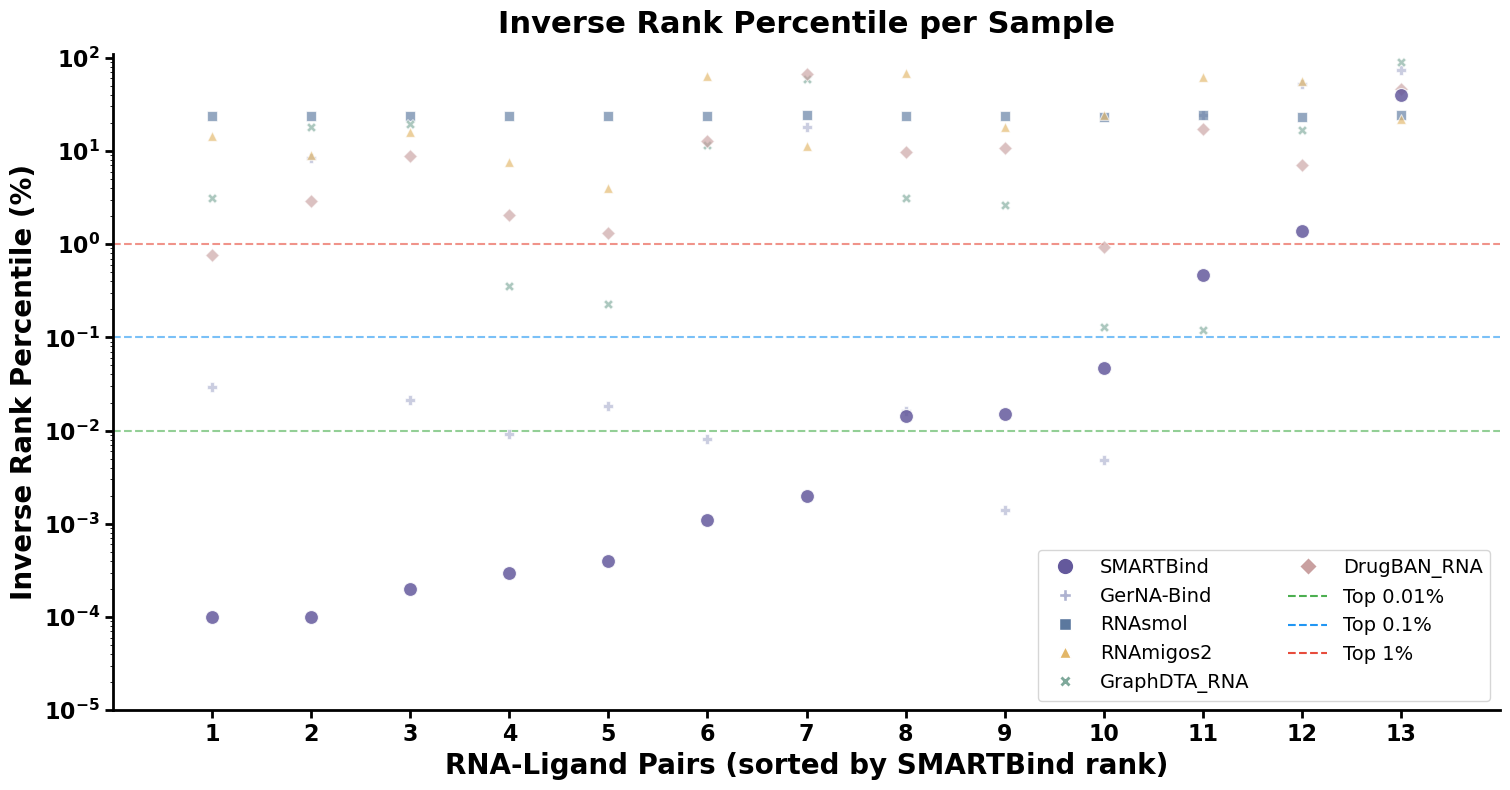

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from matplotlib.lines import Line2D

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	0	0.0218	28.1123	45.5	24.0971	1.0682	13.7552	50.3499	43.6232	2.234	13.0726
0	0	0.0019	20.5276	3.37	11.4852	0.5162	6.6612	27.6688	43.6774	3.1023	44.3417
0	0	0.0012	30.0494	3.86	11.4777	0.136	2.8293	18.4312	36.9397	1.0216	29.5344
0	0	1.3134	13.71	18.37	11.4138	98.5111	26.1495	53.1874	3.2922	88.9497	22.6883
0	0	0.4112	29.5694	20.96	11.4578	99.3592	47.1395	11.4986	3.2304	41.6892	60.0259
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
0	0	0.0167	46.5686	3.67	11.4846	0.8486	4.5399	86.4612	29.5862	0.2191	38.3121
1	0	0.0007	52.0416	16.33	23.8038	2.8677	0.2728	0.8284	6.8369	0.0095	0.1798
1	0	0.0066	54.5291	17.71	23.8127	0.9953	0.1539	7.3622	4.0725	0.0086	0.1771
1	0	0.0038	17.2288	17.7	23.8229	1.8325	0.1257	1.215	2.9371	0.0048	0.3753
1	0	0.0011	40.3711	14.72	23.8177	2.6775	0.1694	0.3101	9.2101	0.0131	0.3472
1	0	0.0007	19.6737	17.66	23.9339	1.7206	0.1375	0.8858	6.5651	0.0152	0.0925
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
1	0	0.1517	38.2882	0.35	11.251	74.1658	55.3776	86.2841	3.559	4.0201	64.3318
1	0	56.8668	11.82	0.37	11.5081	88.4436	83.9511	79.2533	26.7791	82.6332	2.3322
0	0	0.0017	20.8755	15.3848	11.4979	0.4507	5.3955	27.3125	35.6933	10.1937	2.0355
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	0	0.002	26.6181	8.2086	11.4999	1.3145	0.037	31.4435	60.33	0.1495	20.8979
0	0	0.0021	28.053	31.0105	11.4999	1.9425	0.0656	45.2975	88.8545	4.1481	9.0918
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	0	0.0003	80.5214	2.2355	23.2556	0.2371	0.0106	86.7387	75.2199	0.1758	0.44
0	0	0.0162	38.3739	0.5947	11.4999	4.9781	4.171	71.3459	49.117	1.9008	63.7565
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
1	0	2.2076	73.0067	45.1691	11.4604	99.7153	53.4637	68.5215	5.5525	31.4947	30.8514
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	0	0.2907	52.6191	19.5973	24.0664	29.1305	12.0671	59.1727	37.4845	89.1704	79.6051
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
0	0	0.0013	47.5756	10.8691	11.4522	0.0892	5.0833	14.8915	49.313	0.5309	62.311
""".strip()

raw = r"""
Homology-based	Ligand-based	SMARTBind	RNAmigos1	RNAmigos2	RNAsmol	SMARTBind-noAug	GerNA-Bind	GNINA1.3	DeepDocking	DrugBAN_RNA	GraphDTA_RNA
0	1	0.0001	88.9553	14.36	23.5911	0.0029	0.0297	92.04	88.4825	0.7705	3.1459
1	1	0.0001	88.8629	9.11	23.5854	0.5363	8.4196	77.0047	64.8309	2.926	18.0785
1	1	1.3765	71.6699	55.78	22.8833	97.0354	52.8215	89.4032	87.2016	6.9795	16.5963
0	1	0.0002	83.8462	15.8059	23.579	0.0064	0.0213	88.4727	41.1934	8.7794	19.3567
0	1	0.0474	92.8992	24.1831	23.3187	0.2771	0.0048	77.2578	21.9964	0.9223	0.1278
0	1	0.0003	78.6647	7.6258	23.5854	0.2383	0.0091	87.2976	48.8845	2.0406	0.3541
0	1	0.0004	90.5674	3.9801	23.6448	0.2595	0.0183	95.0773	64.0397	1.3282	0.2289
0	1	0.0152	94.9799	17.995	23.8035	0.4251	0.0014	60.2605	29.5963	10.6883	2.6508
1	1	0.4717	10.0554	61.6866	24.0098	38.7512	24.5767	2.8283	24.4149	17.2589	0.1198
1	1	40.1	46.0668	21.9897	24.1316	33.6636	73.0269	15.5797	20.2013	46.5247	90.3301
0	1	0.0011	75.8984	63.214	23.8297	0.0602	0.0081	95.5723	68.8055	12.6189	11.5049
0	1	0.0145	89.3301	69.3553	23.7953	0.4263	0.0164	51.4747	13.0526	9.7487	3.142
1	1	0.002	94.4419	11.195	24.0974	0.6515	17.8769	69.4579	81.6679	66.7796	58.4112
""".strip()

df = pd.read_csv(StringIO(raw), sep="\t")

model_order = ["SMARTBind", "GerNA-Bind", "RNAsmol", "RNAmigos2", "GraphDTA_RNA", "DrugBAN_RNA"]
model_colors_wf = {
    "SMARTBind": "#64599C",
    "GerNA-Bind": "#AEB2D0",
    "RNAsmol": "#5B789E",
    "RNAmigos2": "#E2B668",
    "GraphDTA_RNA": "#7FA99B",
    "DrugBAN_RNA": "#C9A0A0",
}

# Sort samples by SMARTBind rank percentile (ascending)
sorted_idx = df["SMARTBind"].values.argsort()

fig, ax = plt.subplots(figsize=(16*0.95, 8))

x = np.arange(len(sorted_idx))
ax.set_xticks(x)
ax.set_xticklabels(np.arange(1, len(sorted_idx) + 1))

# Marker styles for each model
markers = {
    "SMARTBind": "o",
    "GerNA-Bind": "P",
    "RNAsmol": "s",
    "RNAmigos2": "^",
    "GraphDTA_RNA": "X",
    "DrugBAN_RNA": "D",
}

for model in model_order:
    values = df[model].values[sorted_idx]
    values = np.clip(values, 1e-5, None)
    
    ms = 10 if model == "SMARTBind" else 7
    zorder = 10 if model == "SMARTBind" else 5
    alpha = 0.85 if model == "SMARTBind" else 0.65
    
    ax.scatter(x, values, color=model_colors_wf[model], marker=markers[model],
               s=ms**2, alpha=alpha, zorder=zorder, edgecolors='white', linewidth=0.8,
               label=model)

# Add threshold lines
ax.axhline(y=1.0, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.6, label='Top 1%')
ax.axhline(y=0.1, color='#2196F3', linestyle='--', linewidth=1.5, alpha=0.6, label='Top 0.1%')
ax.axhline(y=0.01, color='#4CAF50', linestyle='--', linewidth=1.5, alpha=0.6, label='Top 0.01%')

ax.set_yscale('log')
ax.set_xlabel('RNA-Ligand Pairs (sorted by SMARTBind rank)', fontsize=20, fontweight='bold')
ax.set_ylabel('Inverse Rank Percentile (%)', fontsize=20, fontweight='bold')
ax.set_title('Inverse Rank Percentile per Sample', fontsize=22, fontweight='bold', pad=15)
ax.set_ylim(1e-5, 110)
ax.set_xlim(-1, len(sorted_idx))

ax.tick_params(axis='both', labelsize=16, width=2, length=6)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

# Custom legend
legend_elements = [
    Line2D([0], [0], marker=markers[m], color='w', markerfacecolor=model_colors_wf[m],
           markersize=12 if m == "SMARTBind" else 9, label=m, markeredgecolor='white')
    for m in model_order
]
legend_elements += [
    Line2D([0], [0], color='#4CAF50', linestyle='--', linewidth=1.5, label='Top 0.01%'),
    Line2D([0], [0], color='#2196F3', linestyle='--', linewidth=1.5, label='Top 0.1%'),
    Line2D([0], [0], color='#E74C3C', linestyle='--', linewidth=1.5, label='Top 1%'),
]
ax.legend(handles=legend_elements, fontsize=14, frameon=True, loc='lower right',
          ncol=2)

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('nc_revision/waterfall_plot.png', dpi=600, bbox_inches='tight')
plt.savefig('nc_revision/waterfall_plot.pdf', bbox_inches='tight')
plt.show()